# Phase 5 — Clustering Experiments

We compare TF-IDF / SBERT / SBERT+categoricals (UMAP-50d) using KMeans and HDBSCAN. `Ticket Subject` is used **only** for evaluation (ARI/AMI), not as an input feature.

In [1]:
import sys
sys.path.append("../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_loader import load_row
from preprocessing import substitute_template_vars, clean_description, drop_noise_columns, parse_dates
from feature_engineering import vectorize_tfidf, embed_sbert, build_combined_features, reduce_umap
from clustering import find_optimal_k, run_kmeans, run_hdbscan, evaluate_clustering

/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load data + prepare features

In [2]:
df = load_row("../data/customer_support_tickets.csv")
df = substitute_template_vars(df)
df["Ticket Description"] = df["Ticket Description"].apply(clean_description)
df = drop_noise_columns(df)
df = parse_dates(df)

true_labels = df["Ticket Subject"].values

X_tfidf, tfidf_vectorizer = vectorize_tfidf(df["Ticket Description"])
X_sbert = embed_sbert(df["Ticket Description"])
X_combined = build_combined_features(X_sbert, df)

X_tfidf_50d = reduce_umap(X_tfidf, n_components=50)
X_sbert_50d = reduce_umap(X_sbert, n_components=50)
X_combined_50d = reduce_umap(X_combined, n_components=50)

print(X_tfidf_50d.shape, X_sbert_50d.shape, X_combined_50d.shape) # type: ignore

/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(8469, 50) (8469, 50) (8469, 50)


## 2. Find optimal k (SBERT UMAP-50d)

We try k from 2 to 20, compute 4 metrics, and find the elbow point on inertia using `kneed`.

In [3]:
opt_results = find_optimal_k(X_sbert_50d, range(2, 21))
elbow_k = opt_results["elbow_k"]
results_df = pd.DataFrame({k: v for k, v in opt_results.items() if k != "elbow_k"})
print("elbow_k:", elbow_k)
results_df

elbow_k: 13


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,801340.50000,0.128867,720.794956,3.309981
1,3,754247.50000,0.160456,647.151561,2.356098
2,4,721147.18750,0.170569,580.696491,2.730525
3,5,673942.56250,0.208172,614.182655,1.379352
4,6,626725.75000,0.244898,655.820126,2.094460
5,7,586239.93750,0.274078,681.587699,1.932093
6,8,548080.00000,0.308082,708.976921,1.841642
7,9,512872.62500,0.315608,735.456940,1.715788
8,10,466307.31250,0.351686,812.793140,1.579869
9,11,441274.78125,0.391821,820.900254,1.519286


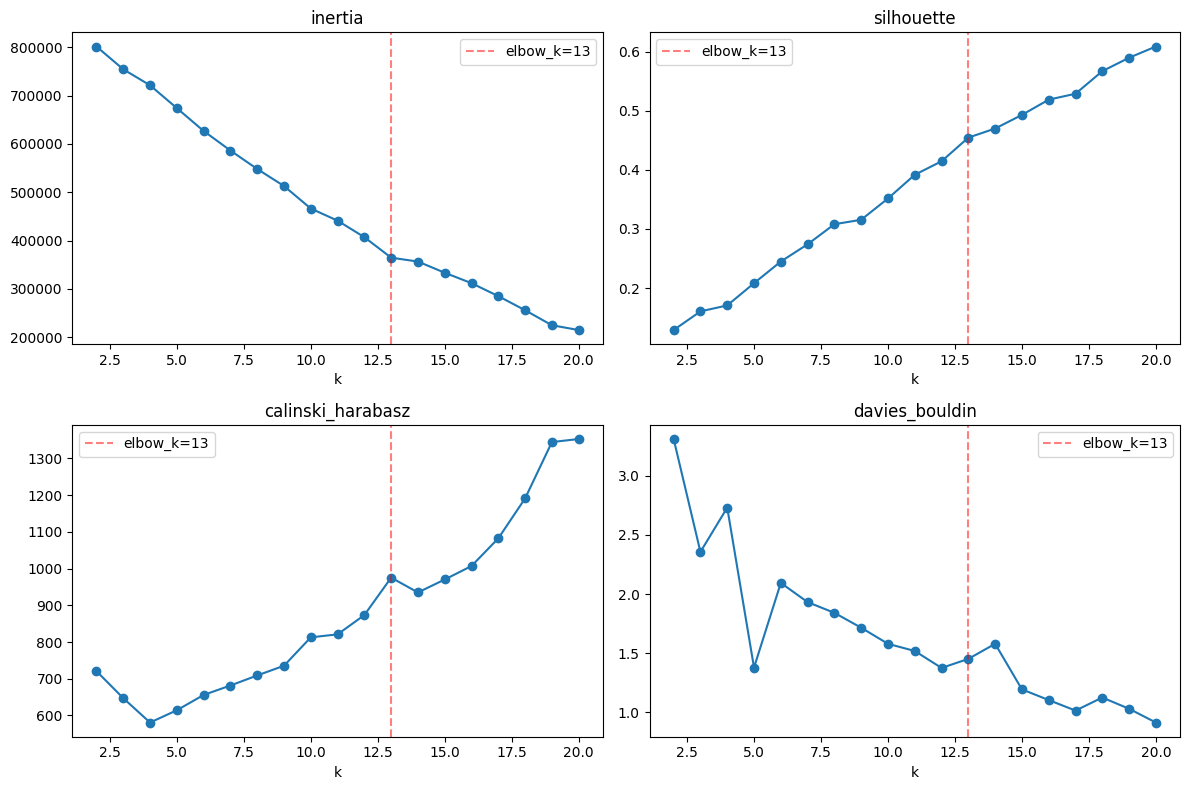

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics_to_plot = ["inertia", "silhouette", "calinski_harabasz", "davies_bouldin"]
for ax, metric in zip(axes.flat, metrics_to_plot):
    ax.plot(results_df["k"], results_df[metric], marker="o")
    ax.set_title(metric)
    ax.set_xlabel("k")
    if elbow_k is not None:
        ax.axvline(elbow_k, color="red", linestyle="--", alpha=0.5, label=f"elbow_k={elbow_k}")
        ax.legend()
plt.tight_layout()
plt.show()

**Observation:** the elbow on inertia gives k=13, but **silhouette does not flatten out** — it keeps growing all the way to k=20 (from 0.13 to 0.61). This means that the more clusters we create, the tighter and cleaner they become — a typical sign of data made of many small, very tight groups, not a few large ones. This matches what we already saw on the UMAP 2D scatter in Phase 4 (dozens of compact mini-clusters). We use `elbow_k=13` as a reasonable compromise for KMeans, but we expect HDBSCAN (which does not need a fixed k) to work better on this kind of structure.

## 3. Experiments: TF-IDF / SBERT / Combined × KMeans / HDBSCAN

In [ ]:
experiments = []

for k in [5, 10, 16]:
    labels, model = run_kmeans(X_tfidf_50d, n_clusters=k)
    m = evaluate_clustering(X_tfidf_50d, labels, true_labels)
    experiments.append({"embedding": "tfidf", "algorithm": f"kmeans_k{k}", "n_clusters_found": len(set(labels)), **m})

labels, model = run_hdbscan(X_tfidf_50d, min_cluster_size=50)
m = evaluate_clustering(X_tfidf_50d, labels, true_labels)
experiments.append({"embedding": "tfidf", "algorithm": "hdbscan_mcs50",
                     "n_clusters_found": len(set(labels)) - (1 if -1 in labels else 0), **m})

for k in [elbow_k, 16]:
    labels, model = run_kmeans(X_sbert_50d, n_clusters=k)
    m = evaluate_clustering(X_sbert_50d, labels, true_labels)
    experiments.append({"embedding": "sbert", "algorithm": f"kmeans_k{k}", "n_clusters_found": len(set(labels)), **m})

labels, model = run_hdbscan(X_sbert_50d, min_cluster_size=50)
m = evaluate_clustering(X_sbert_50d, labels, true_labels)
experiments.append({"embedding": "sbert", "algorithm": "hdbscan_mcs50",
                     "n_clusters_found": len(set(labels)) - (1 if -1 in labels else 0), **m})
sbert_hdbscan_labels = labels  # save for visualization below

for k in [elbow_k, 16]:
    labels, model = run_kmeans(X_combined_50d, n_clusters=k)
    m = evaluate_clustering(X_combined_50d, labels, true_labels)
    experiments.append({"embedding": "combined", "algorithm": f"kmeans_k{k}", "n_clusters_found": len(set(labels)), **m})

labels, model = run_hdbscan(X_combined_50d, min_cluster_size=50)
m = evaluate_clustering(X_combined_50d, labels, true_labels)
experiments.append({"embedding": "combined", "algorithm": "hdbscan_mcs50",
                     "n_clusters_found": len(set(labels)) - (1 if -1 in labels else 0), **m})

results_matrix_df = pd.DataFrame(experiments)
results_matrix_df

## 4. Comparing results and visualizing the best configuration

In [6]:
best_row = results_matrix_df.loc[results_matrix_df["silhouette"].idxmax()]
print(best_row)

embedding                    sbert
algorithm            hdbscan_mcs50
n_clusters_found                48
noise_ratio               0.068131
silhouette                0.886444
calinski_harabasz       28848.5987
davies_bouldin            0.212511
ari                       0.000019
ami                       0.000638
Name: 6, dtype: object


/Users/ayeustsihneyeu/PythonProjects/customer-ticket-cluster/.ticketcluster/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


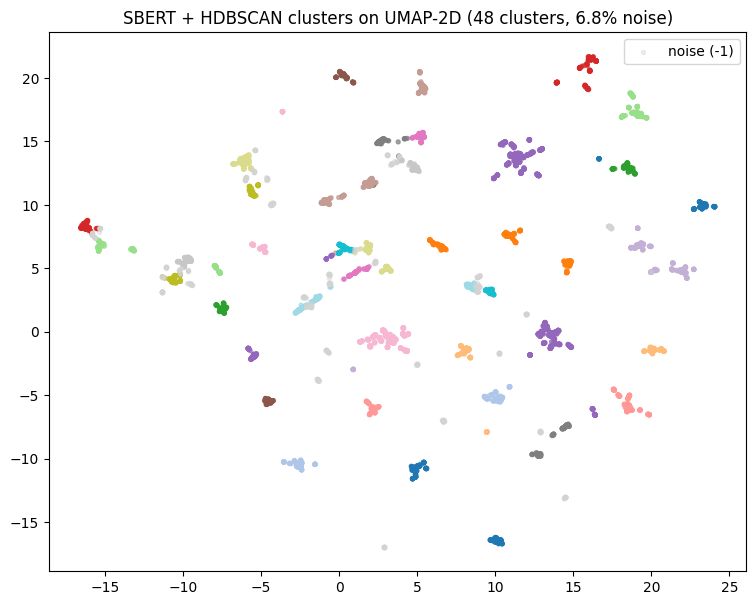

In [ ]:
X_sbert_2d = reduce_umap(X_sbert, n_components=2)
noise_mask = sbert_hdbscan_labels == -1

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_sbert_2d[~noise_mask, 0], X_sbert_2d[~noise_mask, 1], # type: ignore
           c=sbert_hdbscan_labels[~noise_mask], cmap="tab20", s=8, alpha=0.7)
ax.scatter(X_sbert_2d[noise_mask, 0], X_sbert_2d[noise_mask, 1], # type: ignore
           c="lightgray", s=8, alpha=0.4, label="noise (-1)")
ax.set_title(f"SBERT + HDBSCAN clusters on UMAP-2D "
             f"({len(set(sbert_hdbscan_labels)) - 1} clusters, {noise_mask.mean()*100:.1f}% noise)")
ax.legend()
plt.show()

**Main finding of Phase 5 — and it's important to report it honestly, not to force it to match PLAN.md's expectations:**

- **Internal metrics are strong**: the best configuration is SBERT + HDBSCAN, silhouette ≈ 0.89, 48 clusters, 6.8% noise (PLAN.md's threshold is < 30%, easily passed). The clusters look clear and dense on UMAP-2D.
- **But ARI/AMI against `Ticket Subject` are close to 0** in all 11 configurations (from -0.0002 to +0.0006). This means: the clusters we found **do not match** the official ticket category at all.
- This is **not a failure of the method** — it directly confirms what you already found in EDA (Phase 2): the categorical fields in this synthetic dataset are assigned independently of the description text. `Ticket Subject` is a random label that does not reflect the real content of the complaint. Clustering correctly found the real structure (tight groups of descriptions with similar meaning) — this structure is just different from the 16 official categories.
- So what defines these ~48 clusters? It looks like a mix of the template phrase at the start of the description (you found about 10 such phrases in EDA) and the specific product — we will check this in Phase 6 (per-cluster analysis: top terms, representative tickets, product distribution inside each cluster).

## 5. Summary

**What we did:**
1. Reduced the dimensionality of TF-IDF/SBERT/Combined embeddings to 50d using UMAP
2. Chose k for KMeans using `find_optimal_k` (elbow=13, but silhouette has no clear plateau)
3. Ran 11 configurations (3 embeddings × KMeans with different k + HDBSCAN), evaluated with `evaluate_clustering` (internal metrics + ARI/AMI against `Ticket Subject`)
4. The best configuration is **SBERT + HDBSCAN**: high silhouette, low noise, but ARI/AMI ≈ 0

**Main conclusion:** the unsupervised method works correctly and finds a real structure in the text (not noise), but this structure does not match the existing `Ticket Subject` categories — expected for synthetic data, where categories are assigned randomly. For real data, this would be a much bigger warning sign (or a discovery that the official categories don't reflect the actual complaint patterns).

**Next step:** Phase 6 — analysis and visualization (`src/visualization.py`, `notebooks/04_analysis.ipynb`): find out what connects tickets inside each of the ~48 clusters (top TF-IDF terms, representative tickets closest to the centroid/medoid, distribution of Product Purchased inside each cluster).